In [1]:
from google.colab import files
uploaded = files.upload()

Saving barrier_pricer.cpp to barrier_pricer.cpp
Saving fetch_market_data.py to fetch_market_data.py
Saving visualize_results.py to visualize_results.py


In [2]:
!pip install yfinance -q

In [3]:
!python3 fetch_market_data.py

Fetching FX data for INR=X ...
/content/fetch_market_data.py:43: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period, progress=False)
/content/fetch_market_data.py:52: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(close_prices.iloc[-1])
/content/fetch_market_data.py:59: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  annualized_sigma = float(daily_std * np.sqrt(252))
Fetching risk-free rate proxy from ^IRX ...
/content/fetch_market_data.py:69: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="5d", progress=False)
/content/fetch_market_data.py:75: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the fu

In [4]:
!cat inputs.txt

S0=94.95700073242188
K=97.81
barrier=106.35
r=0.037249999046325685
sigma=0.08135473043996778
T=1.0


In [5]:
!g++ -O2 -std=c++17 barrier_pricer.cpp -o barrier_pricer
!./barrier_pricer

Loaded market-derived inputs from inputs.txt

----- OPTION SETUP -----
S0=94.957  K=97.81  r=0.03725  sigma=0.0813547  T=1
Original barrier             : 106.35
Continuity-corrected barrier : 106.668
-------------------------------

[Standard]   N=1000  Price=0.970355  StdError=0.0608025  Time=0.0166762s
[Antithetic] N=1000  Price=0.830704  StdError=0.0345071  Time=0.0203937s
[ControlVar] N=1000  Price=0.871748  StdError=0.0569339  Time=0.016294s
-----------------------------------------------------
[Standard]   N=5000  Price=0.895523  StdError=0.0260721  Time=0.0827338s
[Antithetic] N=5000  Price=0.909221  StdError=0.0160168  Time=0.10121s
[ControlVar] N=5000  Price=0.953147  StdError=0.0264212  Time=0.0854997s
-----------------------------------------------------
[Standard]   N=10000  Price=0.890996  StdError=0.0183331  Time=0.163981s
[Antithetic] N=10000  Price=0.921681  StdError=0.011479  Time=0.204563s
[ControlVar] N=10000  Price=0.907463  StdError=0.0181147  Time=0.169229s
------

Loaded results.csv - preview:
   NumSimulations          Method     Price  StdError  TimeSeconds
0            1000        Standard  0.970355  0.060803     0.016676
1            1000      Antithetic  0.830704  0.034507     0.020394
2            1000  ControlVariate  0.871748  0.056934     0.016294
3            5000        Standard  0.895523  0.026072     0.082734
4            5000      Antithetic  0.909221  0.016017     0.101210
5            5000  ControlVariate  0.953147  0.026421     0.085500
6           10000        Standard  0.890996  0.018333     0.163981
7           10000      Antithetic  0.921681  0.011479     0.204563
8           10000  ControlVariate  0.907463  0.018115     0.169229
9           50000        Standard  0.909858  0.008233     0.830701



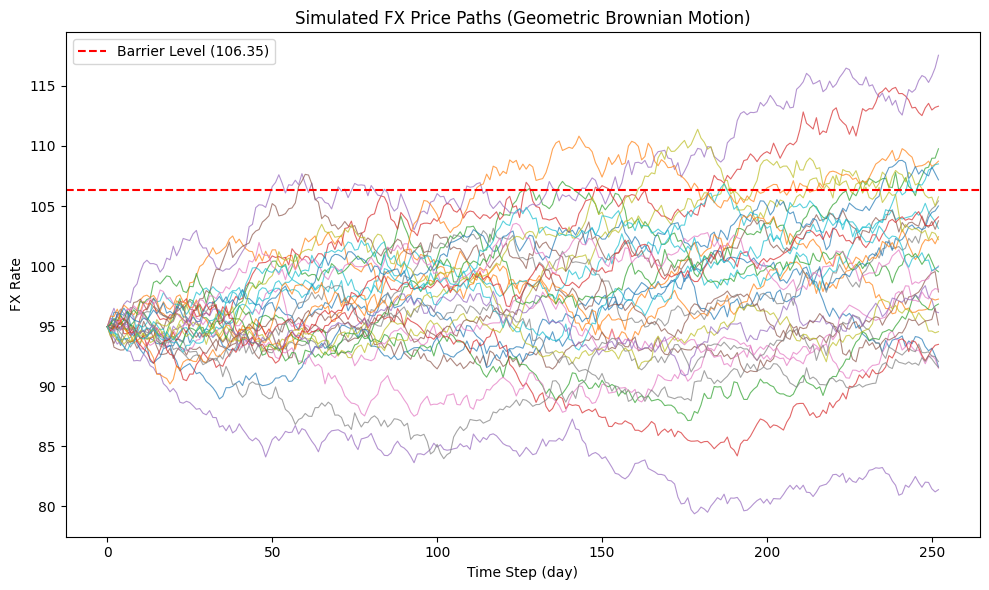

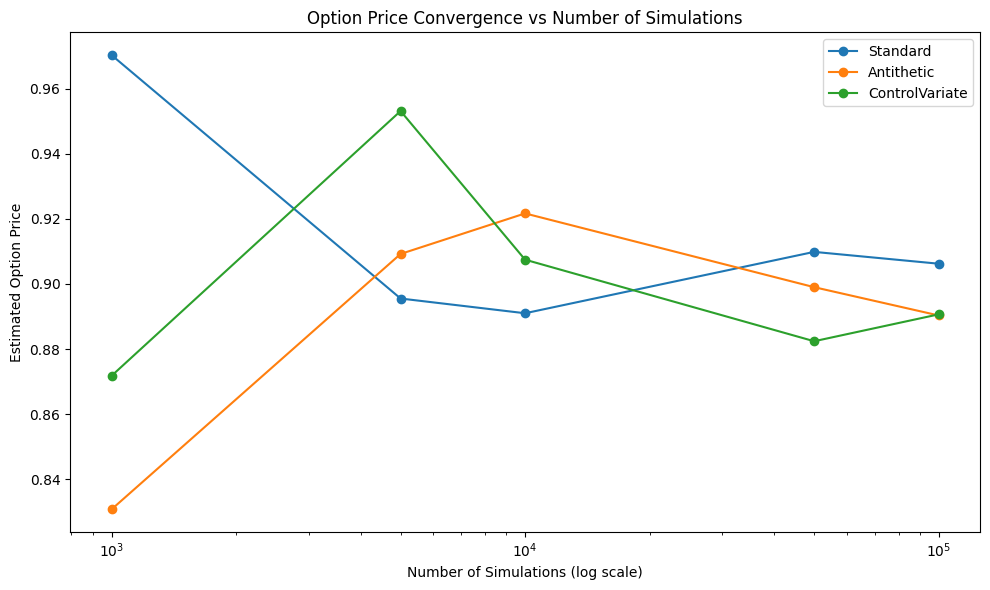

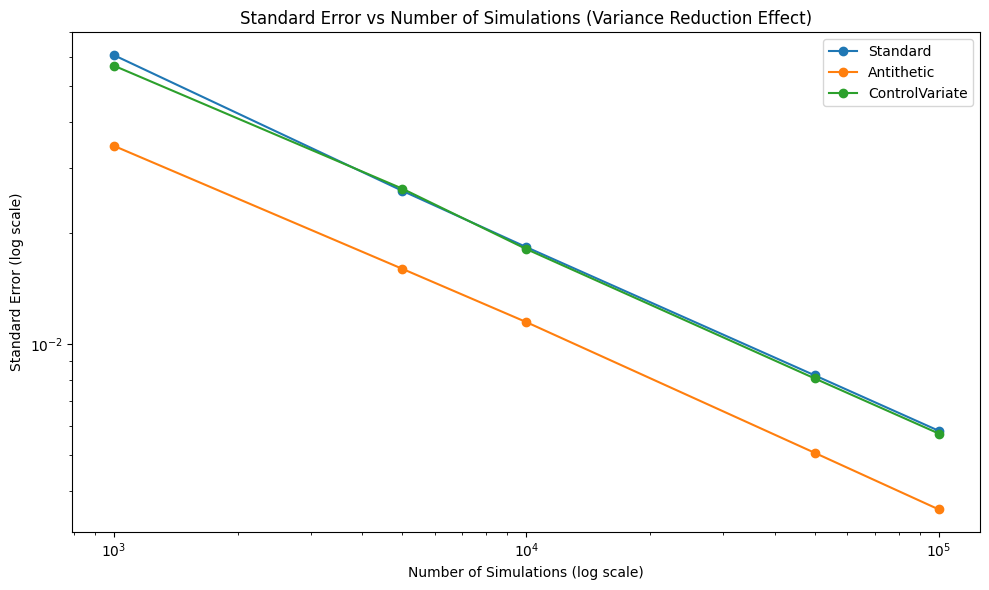

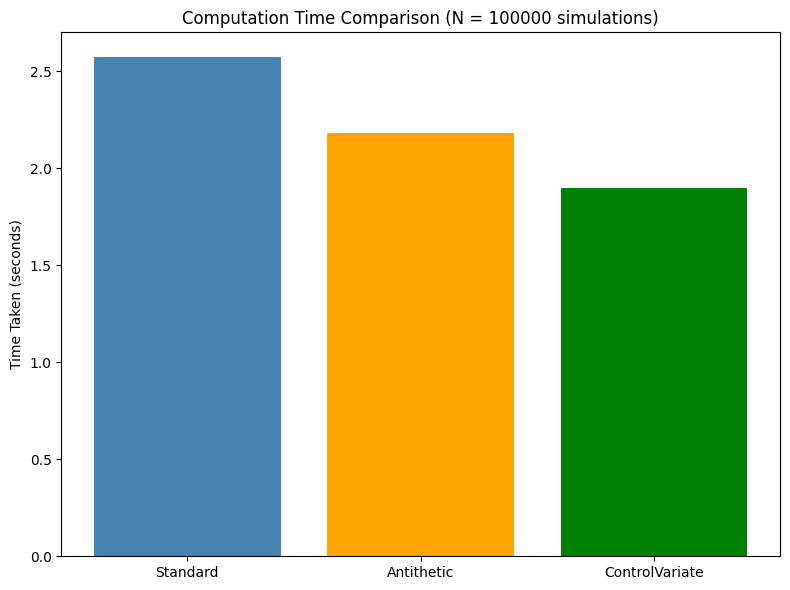


----- CLOSED-FORM VALIDATION (Reiner & Rubinstein, 1991) -----
Closed-form Up-and-Out Call price : 0.754789
(computed using the ORIGINAL barrier, i.e. continuous monitoring assumption)

Comparison at N = 100000:
        Method    Price  ClosedFormPrice  AbsoluteError  ErrorInStdErrors
      Standard 0.906222         0.754789       0.151433         26.009890
    Antithetic 0.890316         0.754789       0.135527         38.030165
ControlVariate 0.890654         0.754789       0.135865         23.738837

'ErrorInStdErrors' close to 0-2 would mean our MC estimate is statistically
consistent with the exact closed-form price. A large gap here (as you may see
for this option) is a genuine, well-documented effect, NOT a bug: this option's
barrier sits close enough to the spot/strike that its value is extremely
sensitive to exactly how often the barrier is checked. The closed-form assumes
CONTINUOUS monitoring (barrier checked at every instant), while our MC checks
only at discrete steps (25

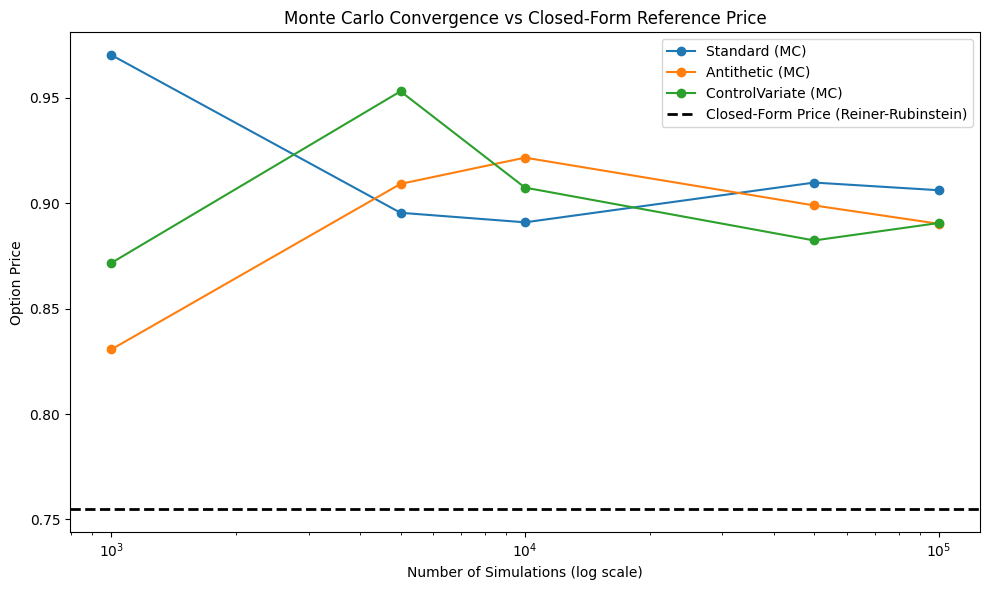


----- VARIANCE REDUCTION EFFICIENCY SUMMARY (at N = 100000) -----
Standard MC Std Error       : 0.005822
Antithetic Std Error        : 0.003564
Control Variate Std Error   : 0.005723

Antithetic Variates are approximately 2.67x more efficient
(i.e., Standard MC would need about 2.67x more simulations
to reach the same accuracy as Antithetic Variates)

Control Variates are approximately 1.03x more efficient
(i.e., Standard MC would need about 1.03x more simulations
to reach the same accuracy as Control Variates)

All plots saved as PNG files in the current folder.
Done!


<Figure size 640x480 with 0 Axes>

In [6]:
!pip install scipy -q   # usually already present in Colab, but just in case
%run visualize_results.py

In [7]:
!ls -la inputs.txt results.csv sample_path.csv multiple_paths.csv

-rw-r--r-- 1 root root     99 Jul  7 19:46 inputs.txt
-rw-r--r-- 1 root root 107201 Jul  7 19:47 multiple_paths.csv
-rw-r--r-- 1 root root    734 Jul  7 19:47 results.csv
-rw-r--r-- 1 root root   2919 Jul  7 19:47 sample_path.csv
